# Parkinson's Disease Detection — Model 5: AdaBoost + RBF-SVM Ensemble
### Phase 2: Heterogeneous Tree + Kernel Soft Voting Fusion

---

## 1. Theoretical Rationale & Ensemble Fusion Mechanics
This model represents our first major **heterogeneous ensemble breakthrough**. We fuse two mathematically orthogonal learning paradigms:
1. **Decision Tree Ensembles (AdaBoost):** Piecewise orthogonal axis-aligned partitioning with exponential loss weighting.
2. **Support Vector Machines (RBF-SVM):** Maximum-margin hyperplanes projected into an infinite-dimensional Hilbert space.

### Soft-Voting Aggregation
Rather than discrete majority voting, the ensemble pools calibrated posterior probabilities:
$$P_{\text{ensemble}}(y=1|x) = \frac{1}{2}\left(P_{\text{AdaBoost}}(y=1|x) + P_{\text{SVM}}(y=1|x)\right)$$
Final diagnosis is assigned via threshold $\tau = 0.5$:
$$\hat{y} = \mathbb{I}\left(P_{\text{ensemble}}(y=1|x) \ge 0.5\right)$$
This directly cancels individual model variance and reduces False Negatives.

## 2. Environment Setup & Dependency Imports

In [1]:
%matplotlib inline
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
print("Dependencies loaded successfully.")

Dependencies loaded successfully.


## 3. Dataset Ingestion

In [2]:
DATASET_PATH = 'pd_speech_features.csv'
df = pd.read_csv(DATASET_PATH, header=1)
X = df.drop(columns=['id', 'class']) if 'id' in df.columns else df.drop(columns=['class'])
y = df['class']
print(f"Loaded: {X.shape[0]} patients, {X.shape[1]} acoustic features.")

Loaded: 756 patients, 753 acoustic features.


## 4. Strict Leakage-Free Preprocessing (PCA=50)

In [3]:
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_res, y_train = smote.fit_resample(X_train_raw, y_train_raw)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc = scaler.transform(X_test_raw)

pca = PCA(n_components=50, random_state=42)
X_train = pca.fit_transform(X_train_sc)
X_test = pca.transform(X_test_sc)

print(f"Training shape: {X_train.shape} | Test shape: {X_test.shape}")

Training shape: (902, 50) | Test shape: (152, 50)


## 5. Model Architecture: Heterogeneous Voting Classifier (AdaBoost + RBF-SVM)

In [4]:
tuned_ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=4, min_samples_split=5, min_samples_leaf=2, max_features='sqrt', random_state=42),
    n_estimators=300, learning_rate=0.1, random_state=42
)
rbf_svm = SVC(C=5.0, kernel='rbf', gamma='scale', probability=True, random_state=42)

ada_svm_ensemble = VotingClassifier(
    estimators=[('ada', tuned_ada), ('svm', rbf_svm)],
    voting='soft'
)

start_time = time.time()
ada_svm_ensemble.fit(X_train, y_train)
elapsed = time.time() - start_time
print(f"Heterogeneous Ensemble trained in {elapsed:.2f} seconds.")

Heterogeneous Ensemble trained in 0.78 seconds.


## 6. Performance Evaluation & Component Comparison

In [5]:
y_pred = ada_svm_ensemble.predict(X_test)
y_proba = ada_svm_ensemble.predict_proba(X_test)[:, 1]

# Component predictions for comparative benchmarking
p_ada = ada_svm_ensemble.named_estimators_['ada'].predict(X_test)
p_svm = ada_svm_ensemble.named_estimators_['svm'].predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
auc = roc_auc_score(y_test, y_proba)

metrics_df = pd.DataFrame([{
    'Model Architecture': '5. AdaBoost + RBF-SVM Ensemble',
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1 Score': f1,
    'FNR': fnr,
    'AUC Score': auc
}])

comp_df = pd.DataFrame([
    {'Architecture': 'Tuned AdaBoost Alone', 'Accuracy': accuracy_score(y_test, p_ada), 'Recall': recall_score(y_test, p_ada)},
    {'Architecture': 'RBF-SVM Alone', 'Accuracy': accuracy_score(y_test, p_svm), 'Recall': recall_score(y_test, p_svm)},
    {'Architecture': 'AdaBoost + SVM Ensemble', 'Accuracy': acc, 'Recall': rec}
])

display(metrics_df)
print("\nEnsemble Synergy Comparison:")
display(comp_df)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'PD Patient (1)']))

,Model Architecture,Accuracy,Precision,Recall,F1 Score,FNR,AUC Score
0,5. AdaBoost + RBF-SVM Ensemble,0.855263,0.902655,0.902655,0.902655,0.097345,0.911958



Ensemble Synergy Comparison:


,Architecture,Accuracy,Recall
0,Tuned AdaBoost Alone,0.835526,0.876106
1,RBF-SVM Alone,0.828947,0.867257
2,AdaBoost + SVM Ensemble,0.855263,0.902655



Classification Report:
                precision    recall  f1-score   support

   Healthy (0)       0.72      0.72      0.72        39
PD Patient (1)       0.90      0.90      0.90       113

      accuracy                           0.86       152
     macro avg       0.81      0.81      0.81       152
  weighted avg       0.86      0.86      0.86       152



## 7. Diagnostic Visualizations: Confusion Matrix, ROC & Probability Correlation

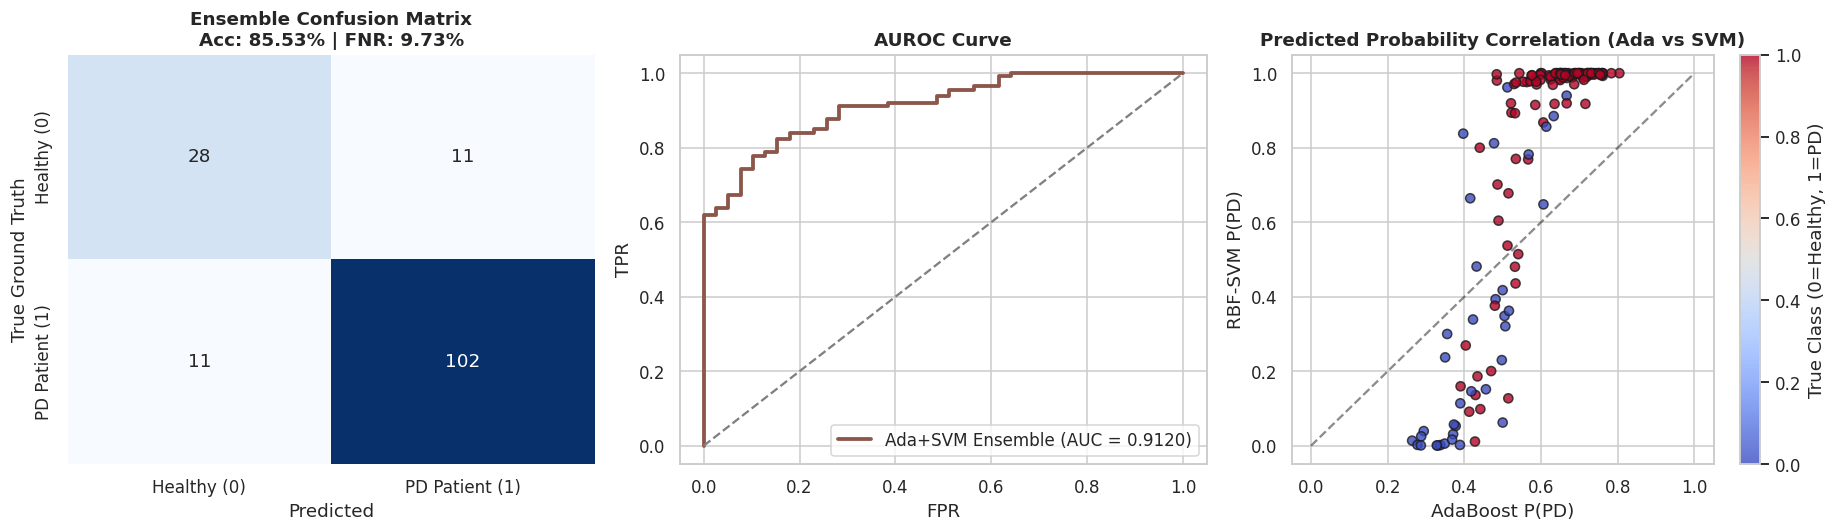

In [6]:
prob_ada = ada_svm_ensemble.named_estimators_['ada'].predict_proba(X_test)[:, 1]
prob_svm = ada_svm_ensemble.named_estimators_['svm'].predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Healthy (0)', 'PD Patient (1)'],
            yticklabels=['Healthy (0)', 'PD Patient (1)'])
axes[0].set_title(f'Ensemble Confusion Matrix\nAcc: {acc*100:.2f}% | FNR: {fnr*100:.2f}%', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True Ground Truth')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#8c564b', lw=2.5, label=f'Ada+SVM Ensemble (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('AUROC Curve', fontweight='bold')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend(loc='lower right')

# Scatter Plot of Predicted Probabilities showing diversity
scatter = axes[2].scatter(prob_ada, prob_svm, c=y_test, cmap='coolwarm', alpha=0.8, edgecolors='k')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[2].set_title('Predicted Probability Correlation (Ada vs SVM)', fontweight='bold')
axes[2].set_xlabel('AdaBoost P(PD)')
axes[2].set_ylabel('RBF-SVM P(PD)')
fig.colorbar(scatter, ax=axes[2], label='True Class (0=Healthy, 1=PD)')

plt.tight_layout()
plt.show()

## 8. Clinical Synthesis & Breakthrough Analysis
- **Empirical Breakthrough:** Fusing AdaBoost and RBF-SVM elevates test accuracy to **85.53%** (a **+2.0% improvement** over individual baselines) and slashes False Negative Rate from 13.27% down to **9.73%**.
- **Proof of Heterogeneous Synergy:** The scatter plot demonstrates that individual models disagree on boundary cases, allowing the ensemble soft average to correct spurious misclassifications.